# Financial Inclusion in Malawi - Descriptive Analysis
## Global Findex 2024 Microdata Analysis

**Author:** Brian Thuwala  

---

## Introduction

This notebook presents the first substantive analytical results of the Malawi Global Findex portfolio project. The objective is to generate weighted descriptive statistics that describe financial inclusion outcomes at the national level and across key population subgroups.

The analysis emphasizes clarity, correctness, and transparency. All reported statistics apply the official survey weight variable and respect survey skip logic. No global deletion of missing values is performed. Variable interpretation follows definitions provided in the official Global Findex codebook.

### Research Questions

This notebook addresses foundational questions including:
- Who owns a financial account in Malawi?
- How does access differ by gender, residence, income, and education?
- Which types of accounts are most common?
- Which population groups remain financially excluded?

These descriptive results establish the empirical baseline for deeper behavioral and policy-focused analysis in subsequent notebooks.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP: Professional Theme, Data Loading & Helpers
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ─── COLOR PALETTE ────────────────────────────────────────────────────────
COLORS = {
    'primary': '#1B4F72', 'secondary': '#2E86C1', 'accent': '#E67E22',
    'success': '#27AE60', 'danger': '#C0392B', 'warning': '#F39C12',
    'light': '#F8F9FA', 'dark': '#2C3E50', 'muted': '#5D6D7E',
    'bg': '#FAFBFC', 'grid': '#E8ECF0', 'text': '#2C3E50',
    'mobile': '#2ECC71', 'bank': '#3498DB', 'total': '#1B4F72',
}
PALETTE_CAT = ['#1B4F72', '#2E86C1', '#27AE60', '#E67E22', '#C0392B', '#8E44AD', '#F39C12']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'], 'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'], 'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'], 'grid.alpha': 0.6, 'grid.linewidth': 0.5,
    'figure.figsize': (14, 7), 'font.size': 11, 'axes.titlesize': 16,
    'axes.labelsize': 12, 'figure.titlesize': 18, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'figure.dpi': 120,
})

def weighted_mean(series, weights):
    valid = series.notna() & weights.notna()
    if valid.sum() == 0: return np.nan
    return np.average(series[valid], weights=weights[valid])

def add_source_note(fig, extra=""):
    txt = "Source: World Bank Global Findex 2024 — Malawi Microdata (n = 1,000; survey-weighted estimates)"
    if extra: txt += f"\n{extra}"
    fig.text(0.02, -0.02, txt, fontsize=10, color=COLORS['muted'], fontstyle='italic', ha='left', va='top')

def styled_table(data, title="", bar_col=None, precision=1):
    styler = data.style.set_caption(title).set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'),('font-weight','bold'),
            ('color', COLORS['primary']),('text-align','left'),('padding-bottom','8px')]},
        {'selector': 'thead th', 'props': [('background-color', COLORS['primary']),('color','white'),
            ('font-weight','bold'),('text-align','center'),('padding','8px 12px'),
            ('border-bottom', f'2px solid {COLORS["accent"]}')]},
        {'selector': 'tbody td', 'props': [('text-align','center'),('padding','6px 12px'),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody th', 'props': [('text-align','left'),('padding','6px 12px'),
            ('font-weight','500'),('background-color', COLORS['light']),
            ('border-bottom', f'1px solid {COLORS["grid"]}')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color','#EBF5FB')]},
        {'selector': '', 'props': [('border-collapse','collapse'),('width','100%')]},
    ]).format(precision=precision)
    if bar_col and bar_col in data.columns:
        styler = styler.bar(subset=[bar_col], color=COLORS['secondary'], vmin=0)
    return styler

def kpi_cards(metrics):
    cards = ""
    for label, value, icon, color in metrics:
        cards += f"""<div style="flex:1;min-width:140px;background:white;border-radius:12px;
            padding:18px 16px;text-align:center;box-shadow:0 2px 12px rgba(0,0,0,0.06);
            border-top:4px solid {color};margin:6px;">
            <div style="font-size:28px;margin-bottom:4px;">{icon}</div>
            <div style="font-size:28px;font-weight:800;color:{color};letter-spacing:-0.5px;">{value}</div>
            <div style="font-size:12px;color:#4a5568;margin-top:4px;line-height:1.3;">{label}</div>
        </div>"""
    display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:8px;justify-content:center;
        padding:10px 0;max-width:900px;margin:auto;">{cards}</div>"""))

print("✅ Professional theme loaded")

✅ Professional theme loaded


**Data Loading**

The analysis reloads the original raw dataset from disk using the same source file validated in Notebook 01. Each notebook is designed to be fully reproducible and does not rely on in-memory objects created in previous notebooks.

In [2]:
DATA_PATH = "../data/raw/Findex_Microdata_2025_updateMalawi.csv"
df = pd.read_csv(DATA_PATH)
print(f"✅ Data loaded: {df.shape[0]:,} respondents × {df.shape[1]} variables")

✅ Data loaded: 1,000 respondents × 199 variables


## Data Validation

Before analysis, verify that constructed variables are properly coded as binary (0/1).

Expected Output: All variables should show [0, 1] or [0.0, 1.0].

In [3]:
# Verify constructed variables are binary (0/1) — styled table
constructed_vars = ['account', 'account_mob', 'account_fin', 'saved', 'borrowed',
                    'anydigpayment', 'merchantpay_dig']
rows = []
for var in constructed_vars:
    if var in df.columns:
        unique_vals = sorted(df[var].dropna().unique())
        ok = set(unique_vals).issubset({0, 1, 0.0, 1.0})
        rows.append({'Variable': var, 'Unique Values': str(unique_vals),
                     'Binary (0/1)': '✅ Yes' if ok else '❌ No'})

display(styled_table(pd.DataFrame(rows).set_index('Variable'),
                     title="🔍 Binary Indicator Validation"))

,Unique Values,Binary (0/1)
Variable,,
account,"[np.int64(0), np.int64(1)]",✅ Yes
account_mob,"[np.int64(0), np.int64(1)]",✅ Yes
account_fin,"[np.int64(0), np.int64(1)]",✅ Yes
saved,"[np.int64(0), np.int64(1)]",✅ Yes
borrowed,"[np.int64(0), np.int64(1)]",✅ Yes
anydigpayment,"[np.int64(0), np.int64(1)]",✅ Yes
merchantpay_dig,"[np.int64(0), np.int64(1)]",✅ Yes


## Methodological Framework

### Survey Weights and Analytical Principles

All population-level statistics in this notebook use the survey weight variable wgt. These weights expand the approximately 1,000 surveyed individuals to represent the national adult population of Malawi.
Key principles:

- Unweighted statistics are not reported unless explicitly stated for diagnostic purposes only
- For binary indicators coded as 1=yes and 0=no, the weighted mean represents the estimated national percentage of adults exhibiting the characteristic
- Missing values represent non-applicable responses and are excluded implicitly through weighted calculations
- Questionnaire variables (coded 1/2/3/4) require conversion to binary for proper interpretation

**Helper function for weighted statistics**

To ensure consistency and transparency, a reusable helper function is used to compute weighted means.

In [4]:
def weighted_mean(series, weights):
    """
    Calculate weighted mean excluding missing values.
    
    Parameters:
    -----------
    series : pd.Series
        Variable to calculate mean for
    weights : pd.Series
        Survey weights
        
    Returns:
    --------
    float : Weighted mean
    """
    valid = series.notna() & weights.notna()
    if valid.sum() == 0: return np.nan
    return np.average(series[valid], weights=weights[valid])

## National Financial Inclusion Overview

### Core Financial Inclusion Indicators

Based on the Global Findex codebook, the following indicators are used as core measures of financial inclusion:
Variable Definitions (From Codebook):

- Account ownership (account): = 1 if the respondent has an account at a financial institution, a mobile money account, or both. = 0 if the respondent does not have an account.
- Mobile money account (account_mob): = 1 if the respondent used mobile money services to pay bills or to send or receive money in the past year. = 0 if the respondent did not use them.
- Bank or formal account (account_fin): = 1 if the respondent had an account at a bank or at another type of financial institution, such as a credit union, a microfinance institution, a cooperative, or the post office (if applicable), or has a debit card. = 0 if the respondent did not have an account.

Note: The codebook specifies that constructed variables include additional respondents identified through skip logic (e.g., those who received wages into an account). See codebook pages 4-5 for full derivation details.

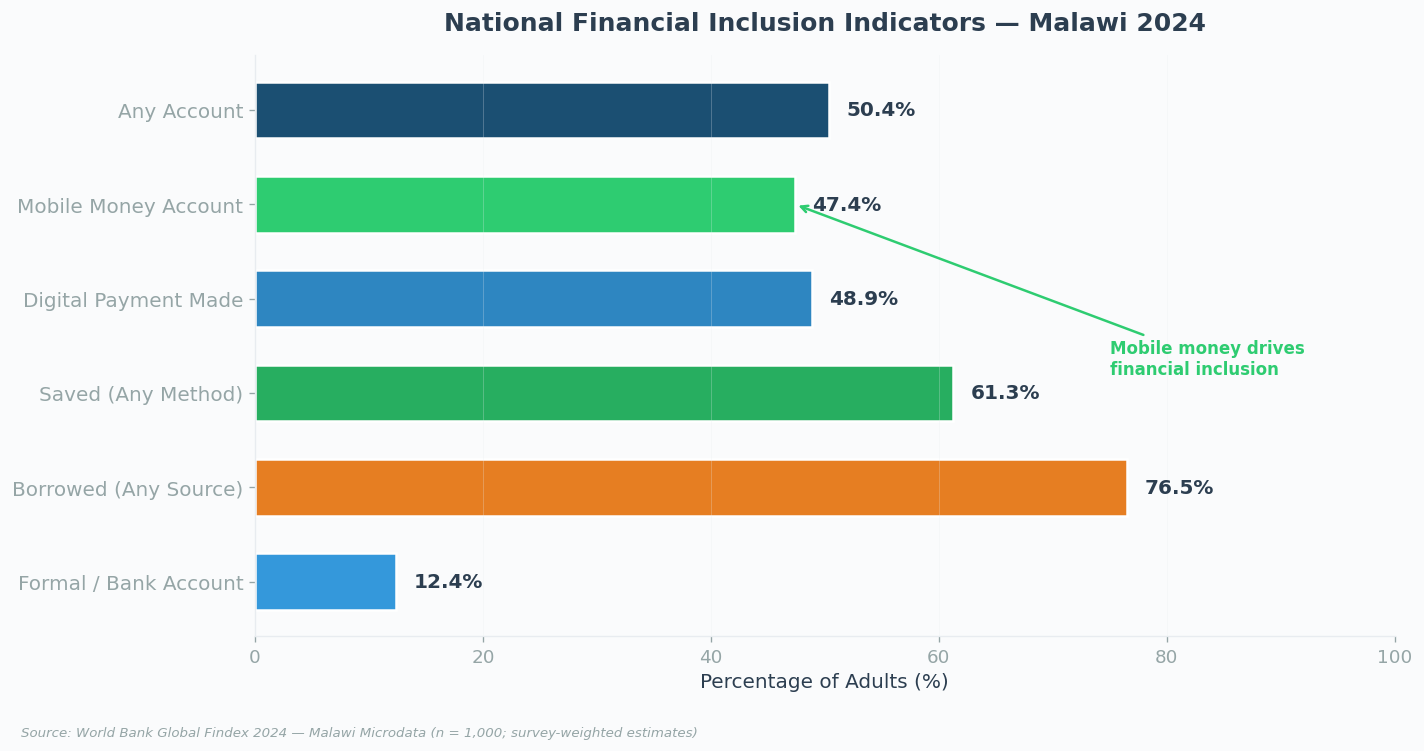

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# NATIONAL FINANCIAL INCLUSION INDICATORS — KPI + Professional Chart
# ═══════════════════════════════════════════════════════════════════════════════

any_acct = weighted_mean(df['account'], df['wgt']) * 100
mobile_acct = weighted_mean(df['account_mob'], df['wgt']) * 100
formal_acct = weighted_mean(df['account_fin'], df['wgt']) * 100
saved_pct = weighted_mean(df['saved'], df['wgt']) * 100
borrowed_pct = weighted_mean(df['borrowed'], df['wgt']) * 100
digpay_pct = weighted_mean(df['anydigpayment'], df['wgt']) * 100

# ─── KPI Cards ───────────────────────────────────────────────────────────
kpi_cards([
    ("Any Account", f"{any_acct:.1f}%", "🏦", COLORS['total']),
    ("Mobile Money", f"{mobile_acct:.1f}%", "📱", COLORS['mobile']),
    ("Formal / Bank", f"{formal_acct:.1f}%", "🏛️", COLORS['bank']),
    ("Saved (any)", f"{saved_pct:.1f}%", "💰", COLORS['success']),
    ("Borrowed (any)", f"{borrowed_pct:.1f}%", "💳", COLORS['accent']),
    ("Digital Payment", f"{digpay_pct:.1f}%", "📲", COLORS['secondary']),
])

# ─── Professional Horizontal Bar Chart ────────────────────────────────────
indicators = {
    'Any Account': any_acct,
    'Mobile Money Account': mobile_acct,
    'Digital Payment Made': digpay_pct,
    'Saved (Any Method)': saved_pct,
    'Borrowed (Any Source)': borrowed_pct,
    'Formal / Bank Account': formal_acct,
}

fig, ax = plt.subplots(figsize=(12, 6))
labels = list(indicators.keys())
values = list(indicators.values())
y_pos = np.arange(len(labels))

bar_colors = [COLORS['total'], COLORS['mobile'], COLORS['secondary'],
              COLORS['success'], COLORS['accent'], COLORS['bank']]

bars = ax.barh(y_pos, values, color=bar_colors, edgecolor='white', linewidth=1.5, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12, fontweight='medium')
ax.invert_yaxis()
ax.set_xlabel('Percentage of Adults (%)', fontsize=12)
ax.set_title('National Financial Inclusion Indicators — Malawi 2024', fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.45)

for bar, v in zip(bars, values):
    ax.text(v + 1.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontweight='bold', fontsize=12, color=COLORS['text'])

# Highlight mobile money dominance
ax.annotate('Mobile money drives\nfinancial inclusion',
            xy=(mobile_acct, 1), xytext=(75, 2.8),
            fontsize=10, color=COLORS['mobile'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['mobile'], lw=1.5))

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/national_indicators.png', dpi=200, bbox_inches='tight')
plt.show()

These results show that financial inclusion in Malawi is driven primarily by mobile money accounts, while ownership of bank or other formal accounts remains substantially lower. This reflects limited banking infrastructure and the central role of mobile money in extending basic financial access.

## Understanding Account Type Overlap

It's important to note that these categories are not mutually exclusive:

- Some adults have both a mobile money account AND a bank account
- The sum of mobile money (47.4%) and bank accounts (12.4%) exceeds total account ownership (50.4%) due to this overlap
- Understanding the overlap helps identify different types of financial consumers

,Share (%)
Category,
Mobile money only,38.0
Bank/formal only,3.0
Both MM & bank,9.4
No account,49.6


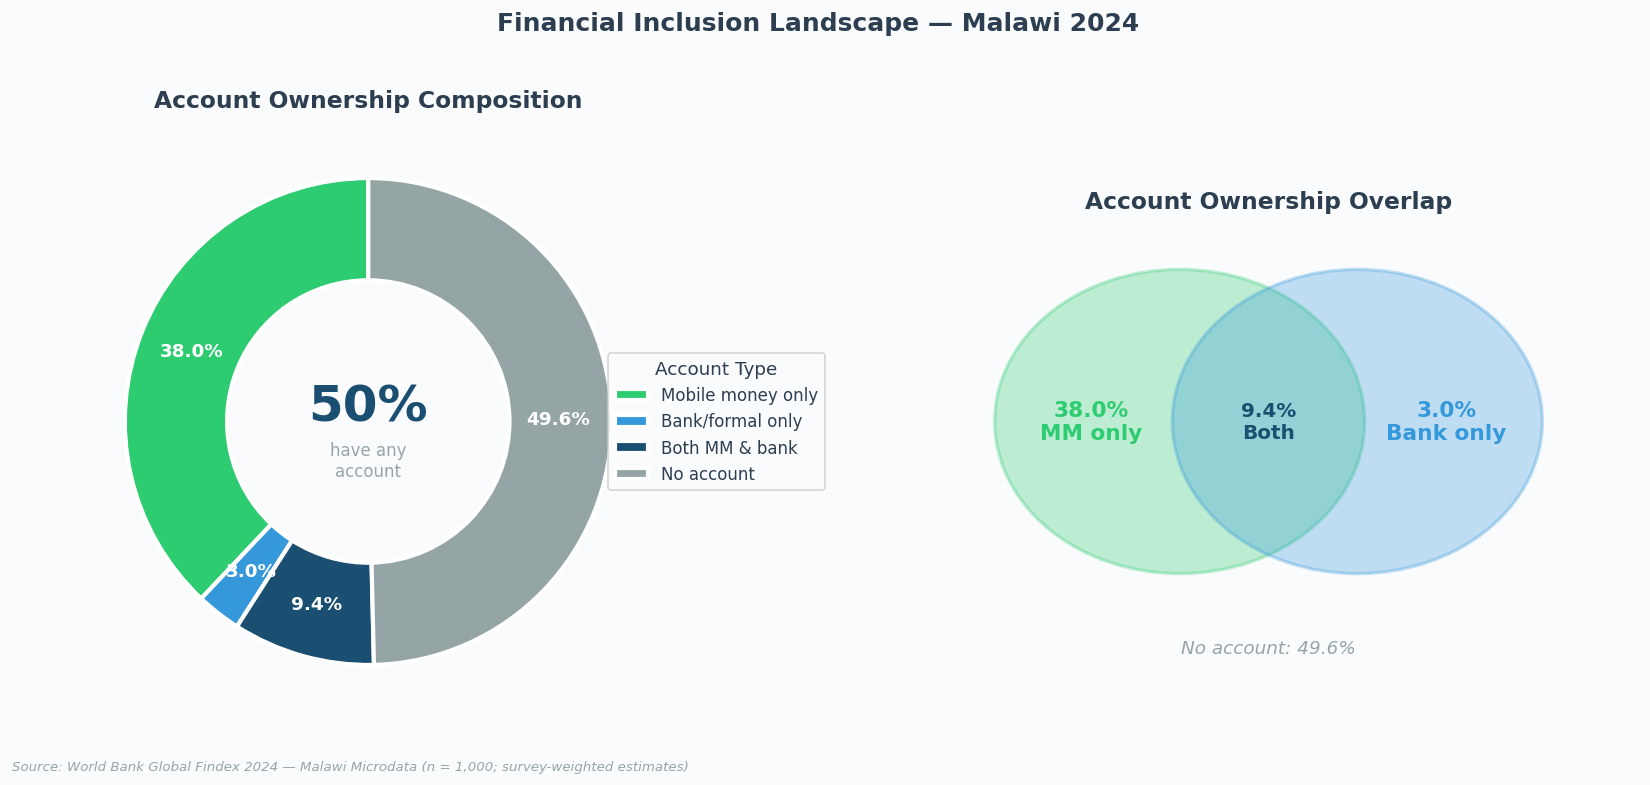

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# ACCOUNT TYPE BREAKDOWN — Mutually Exclusive Categories + Donut Chart
# ═══════════════════════════════════════════════════════════════════════════════

account_breakdown = {
    "Mobile money only": weighted_mean((df['account_mob']==1)&(df['account_fin']==0), df['wgt']) * 100,
    "Bank/formal only":  weighted_mean((df['account_mob']==0)&(df['account_fin']==1), df['wgt']) * 100,
    "Both MM & bank":    weighted_mean((df['account_mob']==1)&(df['account_fin']==1), df['wgt']) * 100,
    "No account":        weighted_mean(df['account']==0, df['wgt']) * 100,
}

# Styled table
breakdown_df = pd.DataFrame({
    'Category': account_breakdown.keys(),
    'Share (%)': account_breakdown.values()
}).set_index('Category')
display(styled_table(breakdown_df, title="📊 Account Type Breakdown (Mutually Exclusive)", bar_col='Share (%)'))

# ─── Professional Donut Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut
ax1 = axes[0]
sizes = list(account_breakdown.values())
labels = list(account_breakdown.keys())
donut_colors = [COLORS['mobile'], COLORS['bank'], COLORS['primary'], COLORS['muted']]

wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, colors=donut_colors, autopct='%1.1f%%', startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5))
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
    t.set_color('white')
centre = plt.Circle((0, 0), 0.36, fc=COLORS['bg'])
ax1.add_artist(centre)
ax1.text(0, 0.06, f'{any_acct:.0f}%', fontsize=30, fontweight='bold', ha='center', va='center', color=COLORS['primary'])
ax1.text(0, -0.16, 'have any\naccount', fontsize=10, ha='center', va='center', color=COLORS['muted'])
ax1.legend(wedges, labels, title='Account Type', loc='center left', bbox_to_anchor=(0.88, 0, 0.5, 1), fontsize=10)
ax1.set_title('Account Ownership Composition', fontweight='bold', fontsize=14)

# Venn-style overlap explanation
ax2 = axes[1]
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis('off')

# Draw overlapping circles
from matplotlib.patches import Circle as MCircle
c1 = MCircle((3.8, 5), 2.5, fill=True, fc=COLORS['mobile'], alpha=0.3, ec=COLORS['mobile'], lw=2)
c2 = MCircle((6.2, 5), 2.5, fill=True, fc=COLORS['bank'], alpha=0.3, ec=COLORS['bank'], lw=2)
ax2.add_patch(c1); ax2.add_patch(c2)

# Labels
mm_only = account_breakdown['Mobile money only']
bank_only = account_breakdown['Bank/formal only']
both_pct = account_breakdown['Both MM & bank']

ax2.text(2.6, 5, f'{mm_only:.1f}%\nMM only', fontsize=13, fontweight='bold', ha='center', va='center', color=COLORS['mobile'])
ax2.text(7.4, 5, f'{bank_only:.1f}%\nBank only', fontsize=13, fontweight='bold', ha='center', va='center', color=COLORS['bank'])
ax2.text(5.0, 5, f'{both_pct:.1f}%\nBoth', fontsize=12, fontweight='bold', ha='center', va='center', color=COLORS['primary'])
ax2.text(5.0, 8.5, 'Account Ownership Overlap', fontsize=14, fontweight='bold', ha='center', color=COLORS['text'])
ax2.text(5.0, 1.2, f'No account: {account_breakdown["No account"]:.1f}%', fontsize=11, ha='center',
         color=COLORS['muted'], style='italic')

plt.suptitle('Financial Inclusion Landscape — Malawi 2024', fontsize=15, fontweight='bold', y=1.02)
add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/account_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()

**Key Insight**: This breakdown reveals how many Malawians rely exclusively on mobile money versus those who have diversified their financial service usage by holding both types of accounts.

## Financial Inclusion by Gender

Gender disparities are a central concern in financial inclusion policy. This section compares account ownership between men and women.

Gender,Female,Male,Gap (pp)
Indicator,,,
Any Account,46.3,54.8,8.6
Mobile Money,43.8,51.4,7.6
Formal/Bank,9.5,15.6,6.2


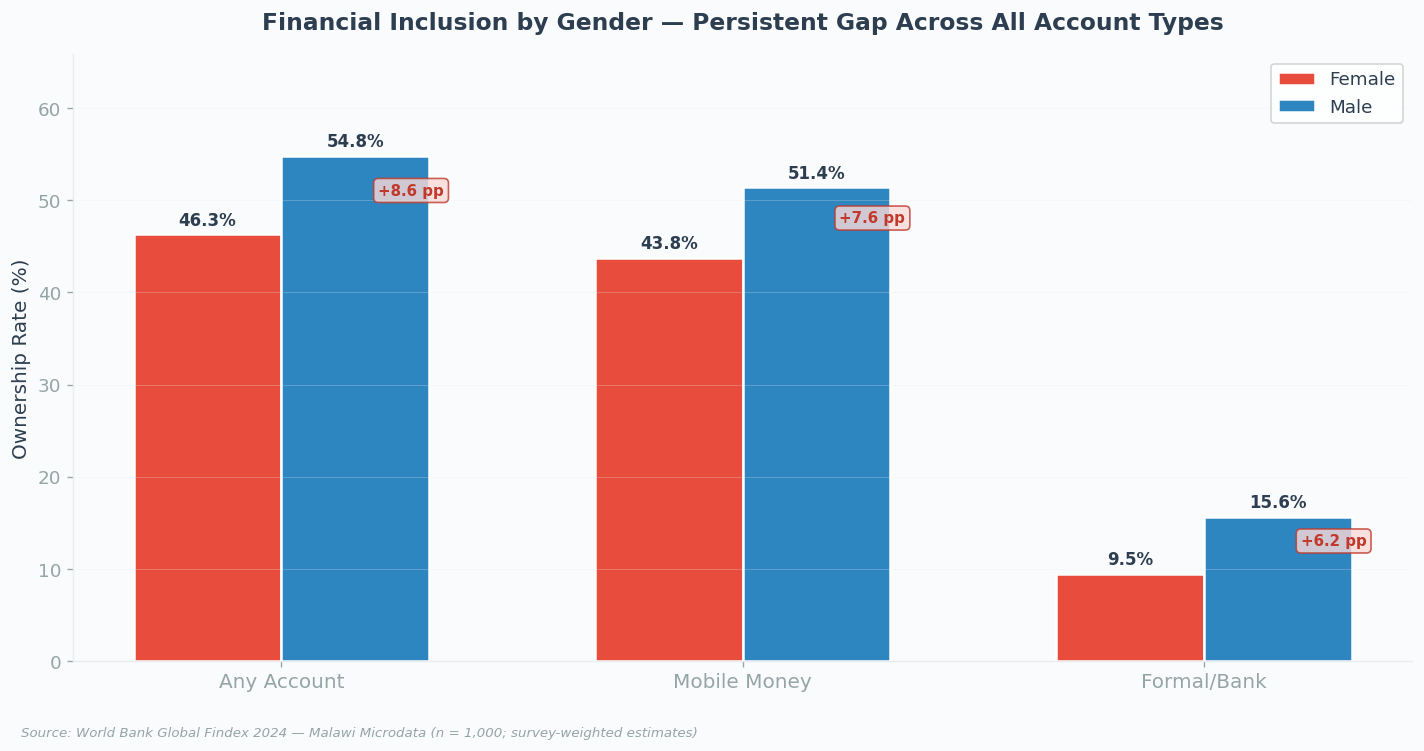

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# GENDER ANALYSIS — Professional Grouped Bar + Gap Annotation
# ═══════════════════════════════════════════════════════════════════════════════

gender_metrics = {}
for var, label in [('account', 'Any Account'), ('account_mob', 'Mobile Money'), ('account_fin', 'Formal/Bank')]:
    for code, gender in [(1, 'Female'), (2, 'Male')]:
        mask = df['female'] == code
        gender_metrics[(label, gender)] = weighted_mean(df.loc[mask, var], df.loc[mask, 'wgt']) * 100

# Build tidy table
gender_df = pd.DataFrame([
    {'Indicator': ind, 'Gender': gen, 'Rate (%)': val}
    for (ind, gen), val in gender_metrics.items()
]).pivot(index='Indicator', columns='Gender', values='Rate (%)').reindex(['Any Account', 'Mobile Money', 'Formal/Bank'])
gender_df['Gap (pp)'] = gender_df['Male'] - gender_df['Female']
display(styled_table(gender_df, title="👫 Account Ownership by Gender (Survey-Weighted)"))

# ─── Professional Grouped Bar Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

indicators_list = ['Any Account', 'Mobile Money', 'Formal/Bank']
x = np.arange(len(indicators_list))
width = 0.32

female_vals = [gender_df.loc[i, 'Female'] for i in indicators_list]
male_vals = [gender_df.loc[i, 'Male'] for i in indicators_list]

bars_f = ax.bar(x - width/2, female_vals, width, label='Female', color='#E74C3C', edgecolor='white', linewidth=1.5)
bars_m = ax.bar(x + width/2, male_vals, width, label='Male', color=COLORS['secondary'], edgecolor='white', linewidth=1.5)

# Value labels
for bars in [bars_f, bars_m]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)

# Gap annotations with arrows
for i, ind in enumerate(indicators_list):
    gap = gender_df.loc[ind, 'Gap (pp)']
    mid_y = (gender_df.loc[ind, 'Female'] + gender_df.loc[ind, 'Male']) / 2
    ax.annotate(f'{gap:+.1f} pp', xy=(i + width/2 + 0.05, mid_y),
                fontsize=9, fontweight='bold', color=COLORS['danger'],
                bbox=dict(boxstyle='round,pad=0.3', fc='#FADBD8', ec=COLORS['danger'], alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels(indicators_list, fontsize=12)
ax.set_ylabel('Ownership Rate (%)')
ax.set_title('Financial Inclusion by Gender — Persistent Gap Across All Account Types', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', fontsize=11)
ax.set_ylim(0, max(max(female_vals), max(male_vals)) * 1.2)
ax.grid(axis='y', alpha=0.45)

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/gender_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

**Gender Breakdown by Account Type**

**Analysis:** The gender gap of approximately 8.6 percentage points indicates that women in Malawi face barriers to financial access compared to men. This gap is consistent with patterns observed across Sub-Saharan Africa and reflects broader gender inequalities in economic participation, asset ownership, and formal employment.

Policy Relevance: The persistent gender gap across both mobile money and bank accounts suggests that barriers are systemic rather than technology-specific.

## Financial Inclusion by Residence

Rural-urban disparities often reflect infrastructure limitations and economic opportunity differences.

Location,Rural,Urban,Gap (pp)
Indicator,,,
Any Account,49.0,62.6,13.6
Mobile Money,46.1,59.1,13.0
Formal/Bank,12.1,15.5,3.4


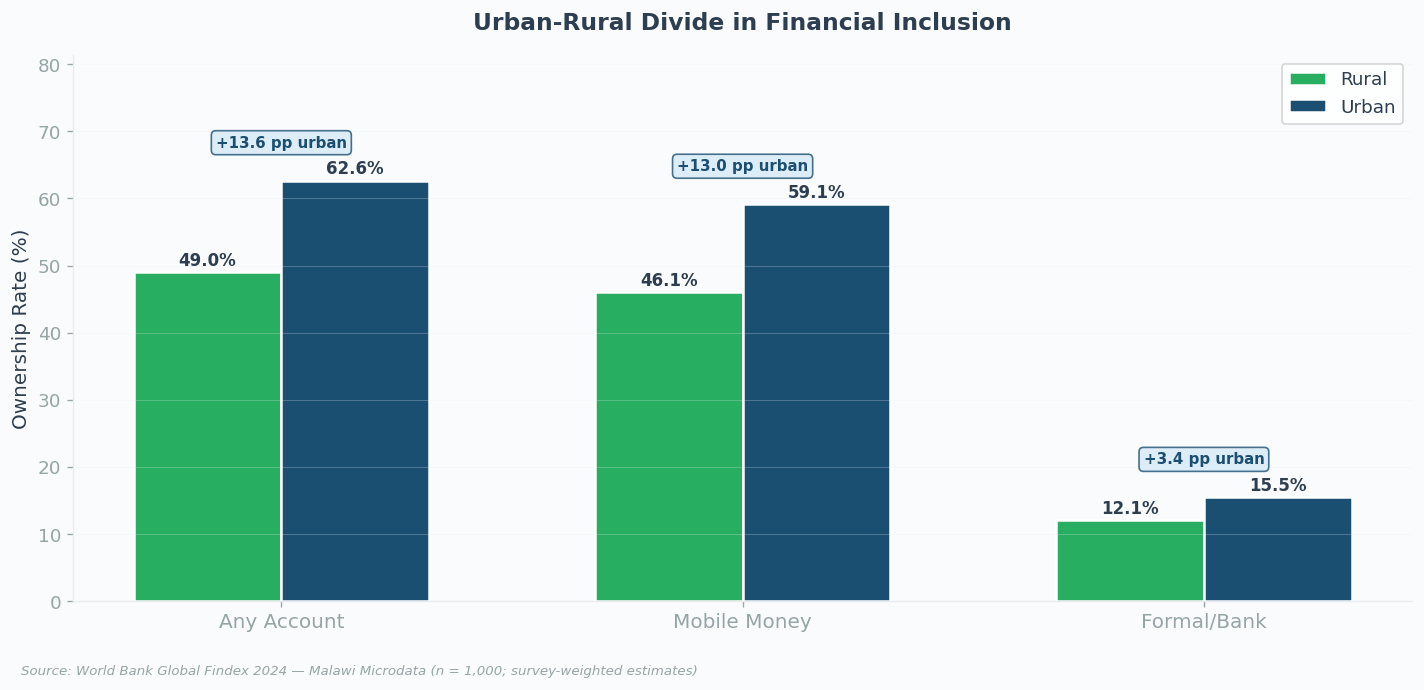

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# RESIDENCE ANALYSIS — Professional Chart + Table
# ═══════════════════════════════════════════════════════════════════════════════

residence_metrics = {}
for var, label in [('account', 'Any Account'), ('account_mob', 'Mobile Money'), ('account_fin', 'Formal/Bank')]:
    for code, loc in [(1, 'Rural'), (2, 'Urban')]:
        mask = df['urbanicity'] == code
        residence_metrics[(label, loc)] = weighted_mean(df.loc[mask, var], df.loc[mask, 'wgt']) * 100

res_df = pd.DataFrame([
    {'Indicator': ind, 'Location': loc, 'Rate (%)': val}
    for (ind, loc), val in residence_metrics.items()
]).pivot(index='Indicator', columns='Location', values='Rate (%)').reindex(['Any Account', 'Mobile Money', 'Formal/Bank'])
res_df['Gap (pp)'] = res_df['Urban'] - res_df['Rural']
display(styled_table(res_df, title="🏘️ Account Ownership by Residence (Survey-Weighted)"))

# ─── Professional Back-to-Back Bar Chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))

indicators_list = ['Any Account', 'Mobile Money', 'Formal/Bank']
x = np.arange(len(indicators_list))
width = 0.32

rural_vals = [res_df.loc[i, 'Rural'] for i in indicators_list]
urban_vals = [res_df.loc[i, 'Urban'] for i in indicators_list]

bars_r = ax.bar(x - width/2, rural_vals, width, label='Rural', color=COLORS['success'], edgecolor='white', linewidth=1.5)
bars_u = ax.bar(x + width/2, urban_vals, width, label='Urban', color=COLORS['primary'], edgecolor='white', linewidth=1.5)

for bars in [bars_r, bars_u]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)

for i, ind in enumerate(indicators_list):
    gap = res_df.loc[ind, 'Gap (pp)']
    mid_y = max(res_df.loc[ind, 'Rural'], res_df.loc[ind, 'Urban']) + 5
    ax.annotate(f'+{gap:.1f} pp urban', xy=(i, mid_y),
                fontsize=9, fontweight='bold', color=COLORS['primary'], ha='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='#D6EAF8', ec=COLORS['primary'], alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels(indicators_list, fontsize=12)
ax.set_ylabel('Ownership Rate (%)')
ax.set_title('Urban-Rural Divide in Financial Inclusion', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', fontsize=11)
ax.set_ylim(0, max(max(rural_vals), max(urban_vals)) * 1.3)
ax.grid(axis='y', alpha=0.45)

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/residence_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

**Analysis:**
While mobile money has expanded access in rural areas, a significant urban-rural gap persists. The gap is particularly pronounced for bank accounts, reflecting the concentration of bank branches in urban centers. Mobile money has partially bridged this infrastructure gap but has not eliminated it entirely.

## Financial Inclusion by Education Level

Education is strongly associated with financial literacy and access to formal employment.

,Any Account (%),Formal/Bank (%),Gap to Tertiary (pp)
Primary or less,43.3,9.3,56.7
Secondary,71.6,21.1,28.4
Tertiary+,100.0,75.4,0.0


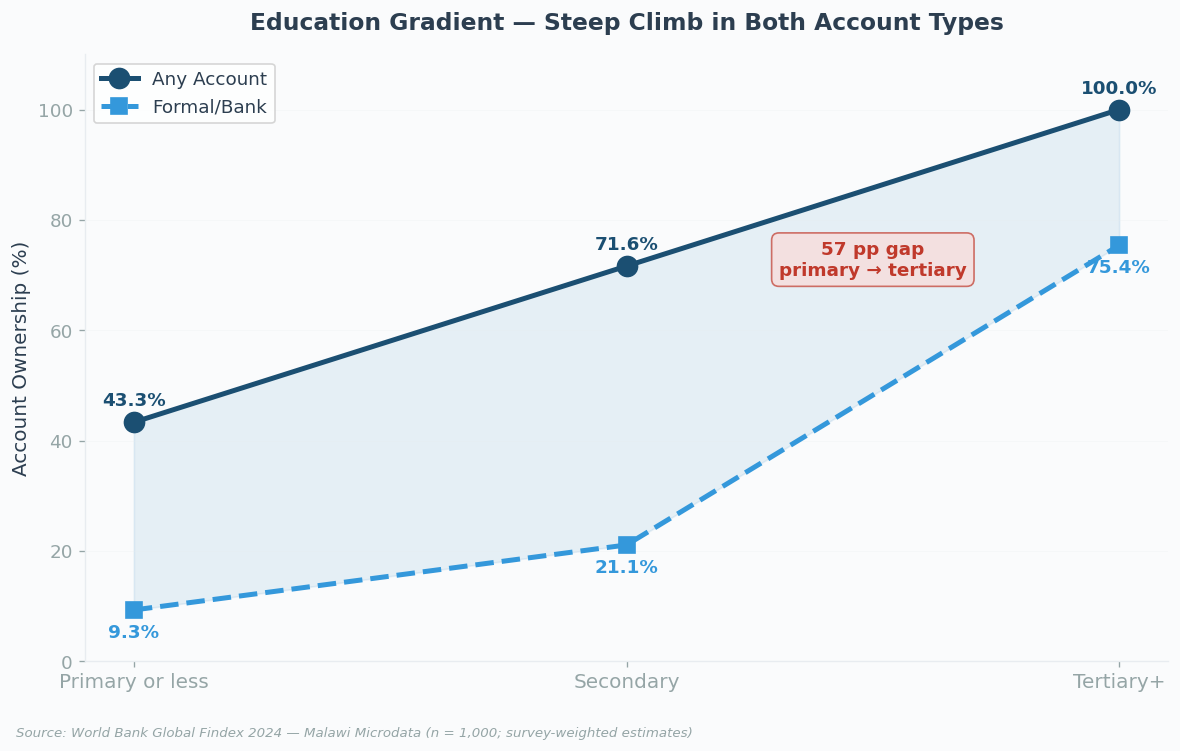

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# EDUCATION GRADIENT — Professional Slope Chart + Table
# ═══════════════════════════════════════════════════════════════════════════════

educ_map = {1: 'Primary or less', 2: 'Secondary', 3: 'Tertiary+'}
educ_metrics = {}
for var, label in [('account', 'Any Account'), ('account_fin', 'Formal/Bank')]:
    for code, ed in educ_map.items():
        mask = df['educ'] == code
        educ_metrics[(label, ed)] = weighted_mean(df.loc[mask, var], df.loc[mask, 'wgt']) * 100

education_results_pct = pd.Series({ed: educ_metrics[('Any Account', ed)] for ed in educ_map.values()})
education_bank_pct = pd.Series({ed: educ_metrics[('Formal/Bank', ed)] for ed in educ_map.values()})

educ_table = pd.DataFrame({
    'Any Account (%)': education_results_pct,
    'Formal/Bank (%)': education_bank_pct,
})
educ_table['Gap to Tertiary (pp)'] = educ_table['Any Account (%)'].iloc[-1] - educ_table['Any Account (%)']
display(styled_table(educ_table, title="🎓 Financial Inclusion by Education Level"))

# ─── Professional Slope Chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ed_labels = list(educ_map.values())
ed_x = [0, 1, 2]

# Any Account line
any_vals_ed = [education_results_pct[l] for l in ed_labels]
bank_vals_ed = [education_bank_pct[l] for l in ed_labels]

ax.plot(ed_x, any_vals_ed, 'o-', color=COLORS['total'], linewidth=3, markersize=12,
        label='Any Account', zorder=5)
ax.plot(ed_x, bank_vals_ed, 's--', color=COLORS['bank'], linewidth=3, markersize=10,
        label='Formal/Bank', zorder=5)

# Fill area between
ax.fill_between(ed_x, bank_vals_ed, any_vals_ed, alpha=0.1, color=COLORS['secondary'])

for i, (a, b, label) in enumerate(zip(any_vals_ed, bank_vals_ed, ed_labels)):
    ax.text(i, a + 3, f'{a:.1f}%', ha='center', fontweight='bold', fontsize=11, color=COLORS['total'])
    ax.text(i, b - 5, f'{b:.1f}%', ha='center', fontweight='bold', fontsize=11, color=COLORS['bank'])

ax.set_xticks(ed_x)
ax.set_xticklabels(ed_labels, fontsize=12)
ax.set_ylabel('Account Ownership (%)')
ax.set_title('Education Gradient — Steep Climb in Both Account Types', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.legend(frameon=True, facecolor='white', fontsize=11)
ax.grid(axis='y', alpha=0.45)

# Annotation
educ_gap = education_results_pct['Tertiary+'] - education_results_pct['Primary or less']
ax.annotate(f'{educ_gap:.0f} pp gap\nprimary → tertiary', xy=(1.5, 70), fontsize=11,
            fontweight='bold', color=COLORS['danger'], ha='center',
            bbox=dict(boxstyle='round,pad=0.4', fc='#FADBD8', ec=COLORS['danger'], alpha=0.7))

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/education_gradient.png', dpi=200, bbox_inches='tight')
plt.show()

**Analysis:** The steep education gradient reveals that financial inclusion is strongly correlated with educational attainment. The 100% account ownership among tertiary-educated adults compared to 43% among those with primary education or less suggests that education affects financial inclusion through multiple channels: higher income, formal employment, financial literacy, and document availability.

**Notable Finding:** The gap is even more pronounced for bank accounts (75% vs 9%), indicating that education particularly affects access to formal banking services.

## Financial Inclusion by Income Quintile

Income is a fundamental determinant of financial inclusion.

,Any Account (%),Mobile Money (%),Formal/Bank (%),Sample N
Poorest 20%,33.2,30.6,5.3,166.0
Second 20%,43.0,39.0,11.2,188.0
Middle 20%,53.8,51.8,13.0,193.0
Fourth 20%,52.0,50.3,7.8,202.0
Richest 20%,69.9,65.3,24.9,251.0


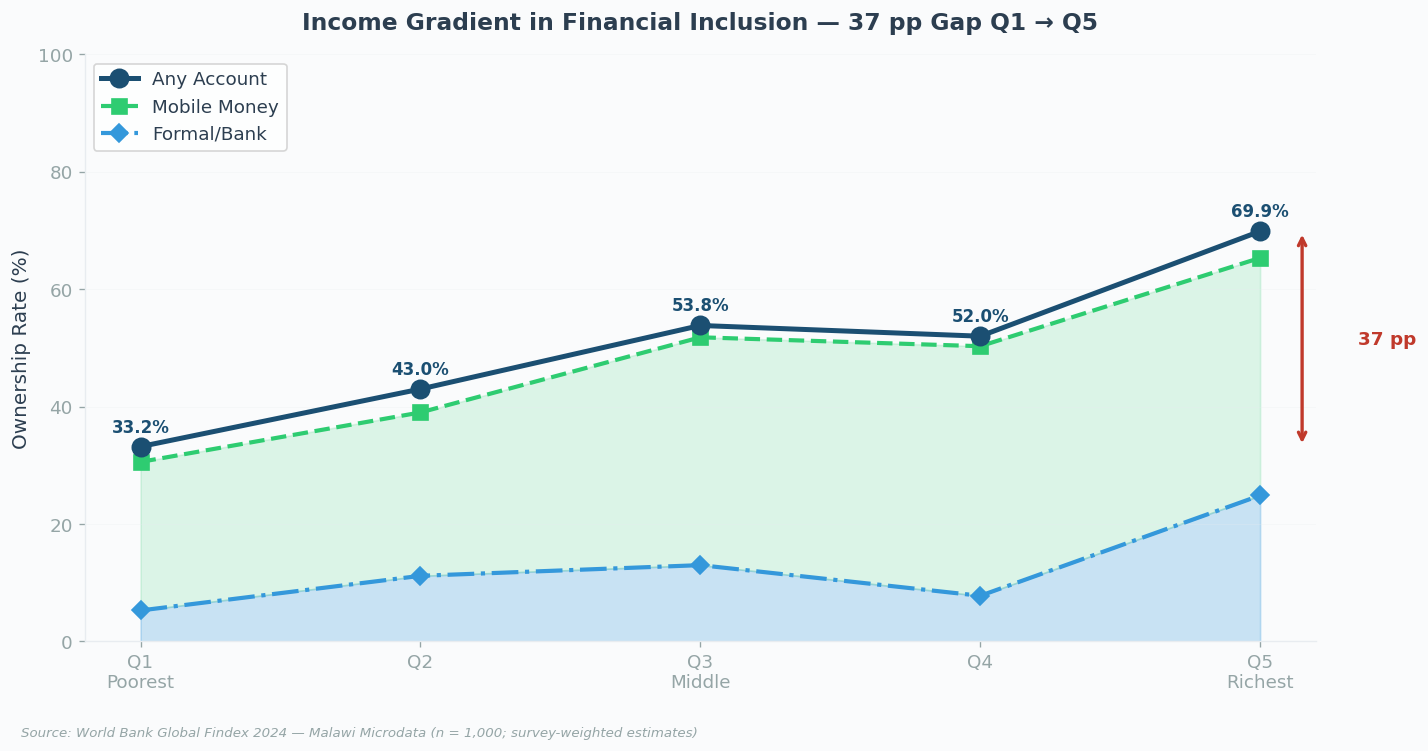

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# INCOME QUINTILE ANALYSIS — Professional Table + Chart
# ═══════════════════════════════════════════════════════════════════════════════

q_labels = {1:'Poorest 20%', 2:'Second 20%', 3:'Middle 20%', 4:'Fourth 20%', 5:'Richest 20%'}
income_data = {}
for q, label in q_labels.items():
    mask = df['inc_q'] == q
    income_data[label] = {
        'Any Account (%)': weighted_mean(df.loc[mask, 'account'], df.loc[mask, 'wgt']) * 100,
        'Mobile Money (%)': weighted_mean(df.loc[mask, 'account_mob'], df.loc[mask, 'wgt']) * 100,
        'Formal/Bank (%)': weighted_mean(df.loc[mask, 'account_fin'], df.loc[mask, 'wgt']) * 100,
        'Sample N': int(mask.sum()),
    }

income_results_pct = pd.DataFrame(income_data).T
income_gap = income_results_pct.loc['Richest 20%', 'Any Account (%)'] - income_results_pct.loc['Poorest 20%', 'Any Account (%)']
display(styled_table(income_results_pct, title="💰 Financial Inclusion by Income Quintile", bar_col='Any Account (%)'))

# ─── Professional Area + Line Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

q_short = ['Q1\nPoorest', 'Q2', 'Q3\nMiddle', 'Q4', 'Q5\nRichest']
x_q = np.arange(5)

any_q = income_results_pct['Any Account (%)'].values
mm_q = income_results_pct['Mobile Money (%)'].values
bank_q = income_results_pct['Formal/Bank (%)'].values

# Area fills
ax.fill_between(x_q, 0, bank_q, alpha=0.25, color=COLORS['bank'])
ax.fill_between(x_q, bank_q, mm_q, alpha=0.15, color=COLORS['mobile'])

# Lines
ax.plot(x_q, any_q, 'o-', color=COLORS['total'], linewidth=3, markersize=11, label='Any Account', zorder=5)
ax.plot(x_q, mm_q, 's--', color=COLORS['mobile'], linewidth=2.5, markersize=9, label='Mobile Money', zorder=4)
ax.plot(x_q, bank_q, 'D-.', color=COLORS['bank'], linewidth=2.5, markersize=8, label='Formal/Bank', zorder=4)

for i in range(5):
    ax.text(i, any_q[i] + 2.5, f'{any_q[i]:.1f}%', ha='center', fontweight='bold', fontsize=10, color=COLORS['total'])

ax.set_xticks(x_q)
ax.set_xticklabels(q_short, fontsize=11)
ax.set_ylabel('Ownership Rate (%)')
ax.set_title(f'Income Gradient in Financial Inclusion — {income_gap:.0f} pp Gap Q1 → Q5',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 100)
ax.legend(frameon=True, facecolor='white', fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.45)

# Highlight the gap
ax.annotate('', xy=(4.15, any_q[4]), xytext=(4.15, any_q[0]),
            arrowprops=dict(arrowstyle='<->', color=COLORS['danger'], lw=2))
ax.text(4.35, (any_q[0]+any_q[4])/2, f'{income_gap:.0f} pp', fontsize=11,
        fontweight='bold', color=COLORS['danger'], va='center')

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/income_gradient.png', dpi=200, bbox_inches='tight')
plt.show()

**Analysis:** The 37 percentage point gap between the richest and poorest quintiles demonstrates that wealth remains a critical barrier to financial inclusion. Even mobile money, despite its lower cost structure, has not fully overcome income-based exclusion. The poorest quintile (33% account ownership) represents a priority segment for inclusive financial policy.

This figure illustrates how financial access is distributed across income quintiles, highlighting inequality in inclusion rather than simple group means.

# Saving and Borrowing Behavior

Beyond account ownership, actual usage of financial services is critical. This section examines saving and borrowing behaviors.

,Rate (%)
Indicator,
Saved (any method),61.3
Borrowed (any source),76.5
Saved at financial institution,5.4
Saved with savings club,37.0
Borrowed from bank/FI,6.7
Borrowed from family/friends,39.6


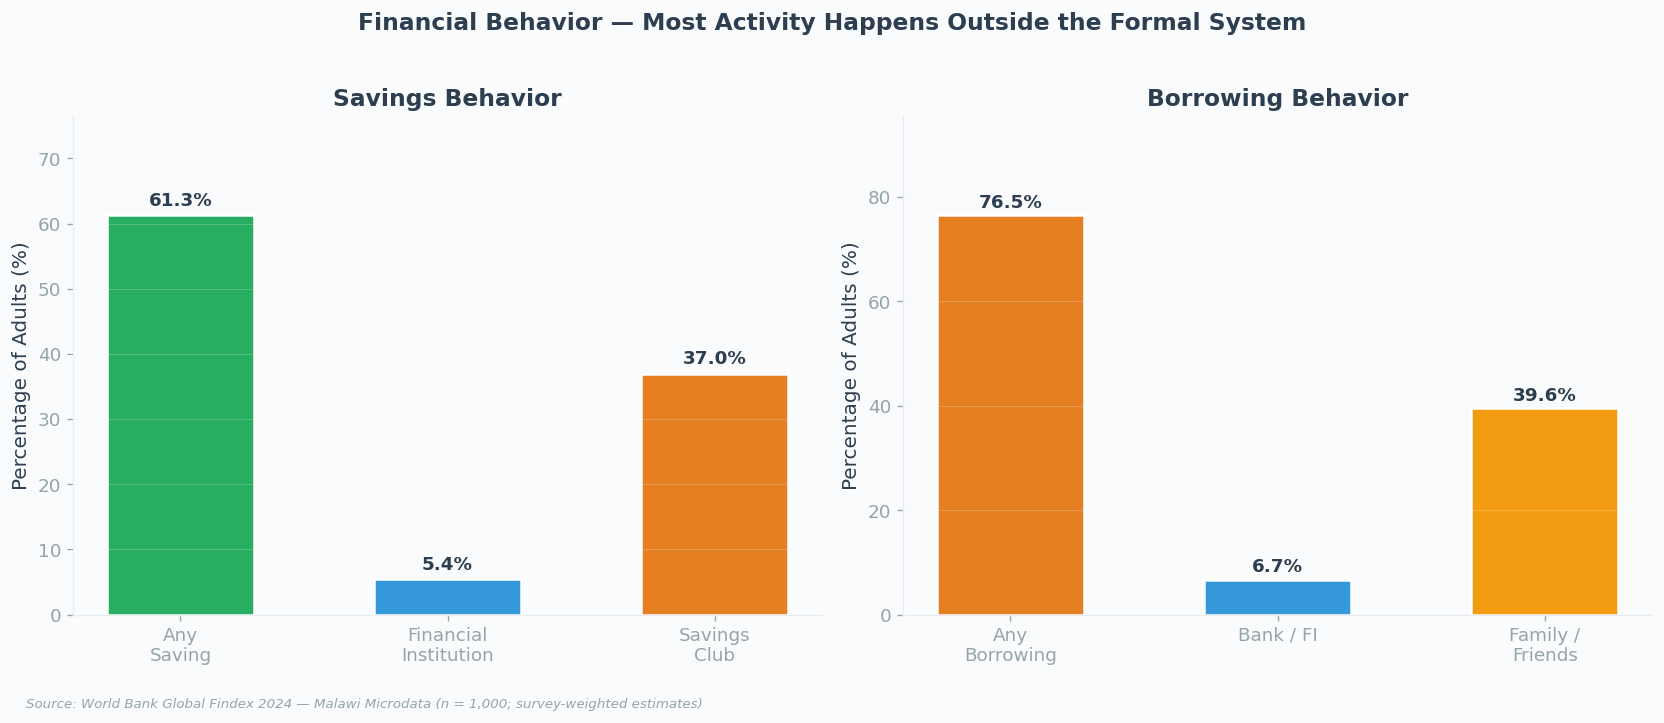

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVINGS & BORROWING — Professional Chart + Table
# ═══════════════════════════════════════════════════════════════════════════════

sb_data = {
    'Saved (any method)': weighted_mean(df['saved'], df['wgt']) * 100,
    'Borrowed (any source)': weighted_mean(df['borrowed'], df['wgt']) * 100,
}

# Saved at financial institution
valid_fin17a = df['fin17a'].isin([1, 2])
if valid_fin17a.sum() > 0:
    sb_data['Saved at financial institution'] = weighted_mean(df.loc[valid_fin17a, 'fin17a'].eq(1), df.loc[valid_fin17a, 'wgt']) * 100
# Saved with savings club
valid_fin17c = df['fin17c'].isin([1, 2])
if valid_fin17c.sum() > 0:
    sb_data['Saved with savings club'] = weighted_mean(df.loc[valid_fin17c, 'fin17c'].eq(1), df.loc[valid_fin17c, 'wgt']) * 100
# Borrowed from bank
if df['fin22a'].isin([1, 2]).sum() > 0:
    sb_data['Borrowed from bank/FI'] = weighted_mean(df.loc[df['fin22a'].isin([1,2]), 'fin22a'].eq(1), df.loc[df['fin22a'].isin([1,2]), 'wgt']) * 100
# Borrowed from family
if df['fin22b'].isin([1, 2]).sum() > 0:
    sb_data['Borrowed from family/friends'] = weighted_mean(df.loc[df['fin22b'].isin([1,2]), 'fin22b'].eq(1), df.loc[df['fin22b'].isin([1,2]), 'wgt']) * 100

sb_table = pd.DataFrame({'Indicator': sb_data.keys(), 'Rate (%)': sb_data.values()}).set_index('Indicator')
display(styled_table(sb_table, title="💰 Savings & Borrowing Behavior", bar_col='Rate (%)'))

# ─── Dual Panel: Savings vs Borrowing ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Savings panel
ax1 = axes[0]
save_labels = ['Any\nSaving', 'Financial\nInstitution', 'Savings\nClub']
save_vals = [sb_data.get('Saved (any method)', 0),
             sb_data.get('Saved at financial institution', 0),
             sb_data.get('Saved with savings club', 0)]
save_colors = [COLORS['success'], COLORS['bank'], COLORS['accent']]
bars = ax1.bar(save_labels, save_vals, color=save_colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylabel('Percentage of Adults (%)')
ax1.set_title('Savings Behavior', fontweight='bold', fontsize=14)
ax1.set_ylim(0, max(save_vals)*1.25)
ax1.grid(axis='y', alpha=0.45)

# Borrowing panel
ax2 = axes[1]
borrow_labels = ['Any\nBorrowing', 'Bank / FI', 'Family /\nFriends']
borrow_vals = [sb_data.get('Borrowed (any source)', 0),
               sb_data.get('Borrowed from bank/FI', 0),
               sb_data.get('Borrowed from family/friends', 0)]
borrow_colors = [COLORS['accent'], COLORS['bank'], COLORS['warning']]
bars = ax2.bar(borrow_labels, borrow_vals, color=borrow_colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel('Percentage of Adults (%)')
ax2.set_title('Borrowing Behavior', fontweight='bold', fontsize=14)
ax2.set_ylim(0, max(borrow_vals)*1.25)
ax2.grid(axis='y', alpha=0.45)

plt.suptitle('Financial Behavior — Most Activity Happens Outside the Formal System',
             fontsize=14, fontweight='bold', y=1.02)
add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/savings_borrowing.png', dpi=200, bbox_inches='tight')
plt.show()

**Mobile Money Savings (Conditional Analysis)**

In [12]:
# Borrowing from different sources
# Note: These variables use 1=yes, 2=no coding
borrowing_sources = {}

# From financial institution (fin22a)
if df["fin22a"].isin([1, 2]).sum() > 0:
    borrowing_sources["Borrowed from bank/FI"] = weighted_mean(
        df.loc[df["fin22a"].isin([1, 2]), "fin22a"].eq(1),
        df.loc[df["fin22a"].isin([1, 2]), "wgt"]
    )

# From family or friends (fin22b)
if df["fin22b"].isin([1, 2]).sum() > 0:
    borrowing_sources["Borrowed from family/friends"] = weighted_mean(
        df.loc[df["fin22b"].isin([1, 2]), "fin22b"].eq(1),
        df.loc[df["fin22b"].isin([1, 2]), "wgt"]
    )

# From savings club (fin22c) - only asked of savings club members
if df["fin22c"].isin([1, 2]).sum() > 0:
    borrowing_sources["Borrowed from savings club"] = weighted_mean(
        df.loc[df["fin22c"].isin([1, 2]), "fin22c"].eq(1),
        df.loc[df["fin22c"].isin([1, 2]), "wgt"]
    )

borrowing_sources_pct = {k: v * 100 for k, v in borrowing_sources.items()}

print("\n" + "=" * 60)
print("BORROWING SOURCES")
print("=" * 60)
for source, value in borrowing_sources_pct.items():
    print(f"{source:.<40} {value:>6.2f}%")
print("=" * 60)
print("\nNote: These are not mutually exclusive - individuals may")
print("borrow from multiple sources.")


BORROWING SOURCES
Borrowed from bank/FI...................   6.69%
Borrowed from family/friends............  39.55%
Borrowed from savings club..............  70.43%

Note: These are not mutually exclusive - individuals may
borrow from multiple sources.


## Digital Payment Usage

Digital financial services are increasingly important for financial inclusion.

**Digital Payment Indicators - Important Notes**
Different indicators have different denominators:

- Made/received digital payment (anydigpayment): Calculated among ALL adults (population-level)
- Made digital merchant payment (merchantpay_dig): Calculated among ALL adults (population-level)
- Used card/phone in-store (fin25e2): Calculated among ACCOUNT HOLDERS ONLY (conditional)


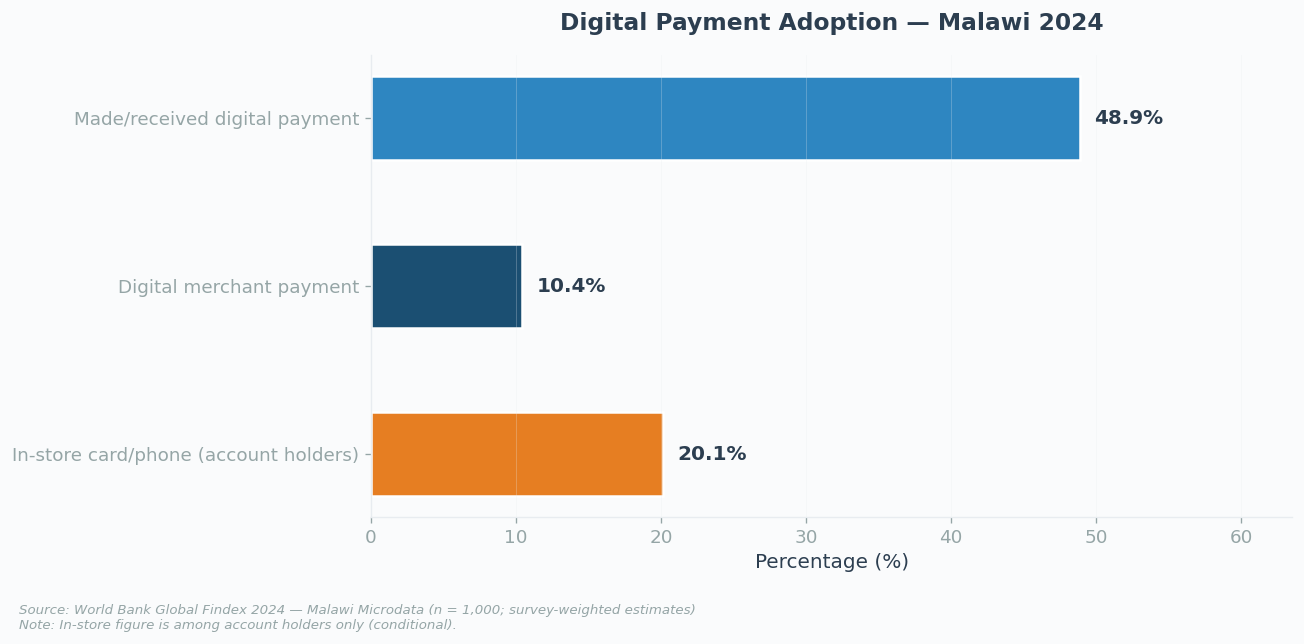

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# DIGITAL PAYMENTS — Professional Visualization
# ═══════════════════════════════════════════════════════════════════════════════

dig_data = {
    'Made/received digital payment': weighted_mean(df['anydigpayment'], df['wgt']) * 100,
    'Digital merchant payment': weighted_mean(df['merchantpay_dig'], df['wgt']) * 100,
}

# In-store digital (conditional)
instore_valid = df['fin25e2'].isin([1, 2])
if instore_valid.sum() > 0:
    instore_pct = weighted_mean(df.loc[instore_valid, 'fin25e2'].eq(1), df.loc[instore_valid, 'wgt']) * 100
    dig_data['In-store card/phone (account holders)'] = instore_pct

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(dig_data.keys())
values = list(dig_data.values())
colors_dig = [COLORS['secondary'], COLORS['primary'], COLORS['accent']][:len(values)]

bars = ax.barh(labels, values, color=colors_dig, edgecolor='white', linewidth=1.5, height=0.5)
for bar, v in zip(bars, values):
    ax.text(v + 1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontweight='bold', fontsize=12)

ax.set_xlabel('Percentage (%)')
ax.set_title('Digital Payment Adoption — Malawi 2024', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.set_xlim(0, max(values)*1.3)
ax.grid(axis='x', alpha=0.45)

add_source_note(fig, "Note: In-store figure is among account holders only (conditional).")
plt.tight_layout()
plt.savefig('../outputs/figures/digital_payments.png', dpi=200, bbox_inches='tight')
plt.show()

**Digital Payments Among Account Holders (Conditional)**

## Economic Participation and Financial Access

This figure compares participation in income receiving activities between adults with and without formal financial accounts.

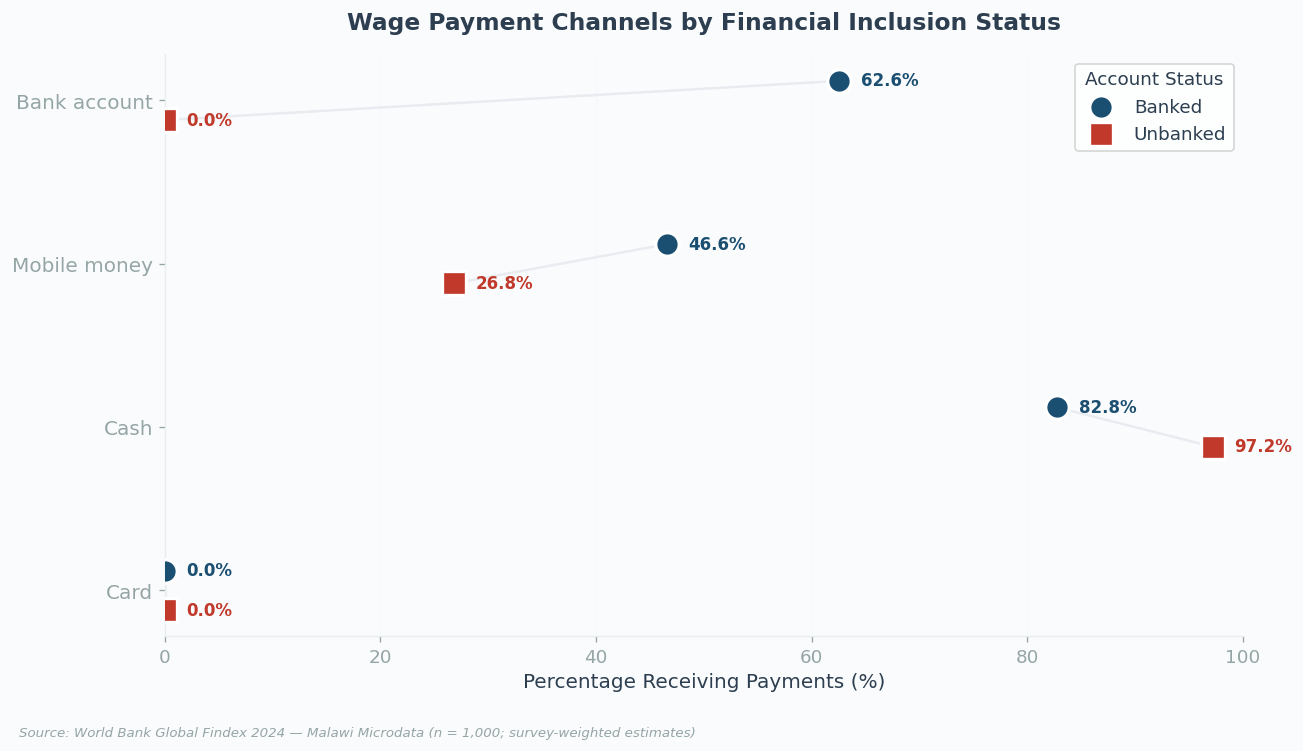

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# WAGE PAYMENT CHANNELS — Professional Dot Plot
# ═══════════════════════════════════════════════════════════════════════════════

channels = {"Bank account": "fin34a", "Mobile money": "fin34b", "Cash": "fin34c", "Card": "fin34d"}
plot_data = []

for label, var in channels.items():
    for status, acc_label in [(1, "Banked"), (0, "Unbanked")]:
        subset = df['account_fin'] == status
        valid = subset & df[var].isin([1, 2])
        if valid.sum() > 0:
            rate = weighted_mean(df.loc[valid, var].eq(1), df.loc[valid, 'wgt']) * 100
        else:
            rate = 0
        plot_data.append({"Channel": label, "Status": acc_label, "Rate": rate})

plot_df = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(11, 6))

channels_list = list(channels.keys())
y_pos = np.arange(len(channels_list))

for status, marker, color, offset in [('Banked', 'o', COLORS['primary'], -0.12),
                                        ('Unbanked', 's', COLORS['danger'], 0.12)]:
    sub = plot_df[plot_df['Status'] == status]
    rates = [sub[sub['Channel']==ch]['Rate'].values[0] if len(sub[sub['Channel']==ch]) > 0 else 0 for ch in channels_list]
    ax.scatter(rates, y_pos + offset, s=200, color=color, marker=marker, edgecolors='white',
               linewidth=2, zorder=5, label=status)
    for i, r in enumerate(rates):
        ax.text(r + 2, y_pos[i] + offset, f'{r:.1f}%', va='center', fontsize=10, fontweight='bold', color=color)

# Connect dots with lines
for i, ch in enumerate(channels_list):
    banked_r = plot_df[(plot_df['Channel']==ch) & (plot_df['Status']=='Banked')]['Rate'].values
    unbanked_r = plot_df[(plot_df['Channel']==ch) & (plot_df['Status']=='Unbanked')]['Rate'].values
    if len(banked_r) and len(unbanked_r):
        ax.plot([unbanked_r[0], banked_r[0]], [i+0.12, i-0.12], color=COLORS['grid'], lw=1.5, zorder=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(channels_list, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel('Percentage Receiving Payments (%)')
ax.set_title('Wage Payment Channels by Financial Inclusion Status', fontsize=14, fontweight='bold', pad=15)
ax.legend(frameon=True, facecolor='white', fontsize=11, title='Account Status')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.45)

add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/wage_channels.png', dpi=200, bbox_inches='tight')
plt.show()

## Intersectional Analysis: Gender × Residence

Understanding how multiple dimensions interact is crucial for targeted interventions.


urbanicity,Rural,Urban
female,,
Female,44.4,59.1
Male,53.7,69.5


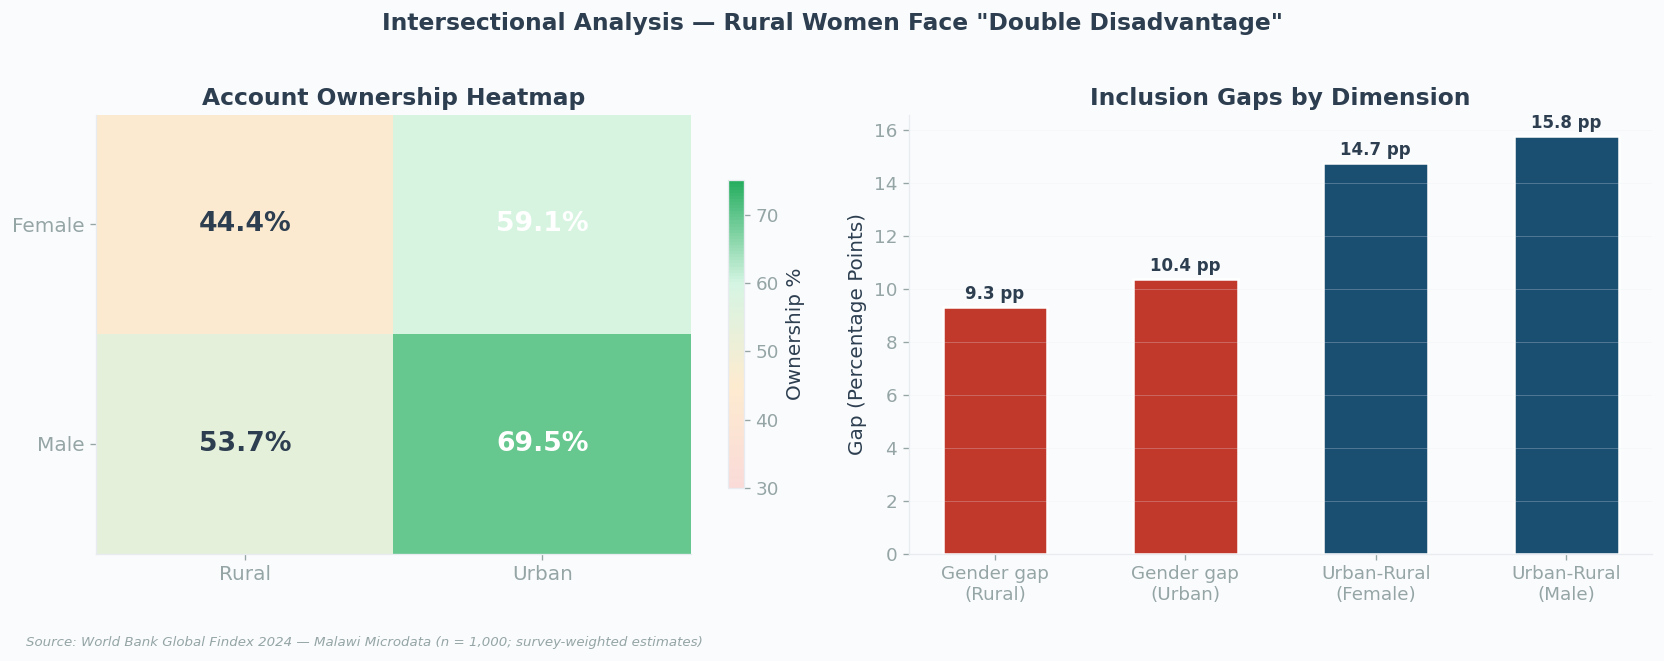

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTERSECTIONAL ANALYSIS: Gender × Residence — Professional Heatmap + Table
# ═══════════════════════════════════════════════════════════════════════════════

gender_residence = (
    df.loc[df['female'].isin([1,2]) & df['urbanicity'].isin([1,2])]
    .groupby(['female', 'urbanicity'])['account']
    .agg(lambda x: weighted_mean(x, df.loc[x.index, 'wgt']))
    .unstack()
)
gender_residence.index = gender_residence.index.map({1:'Female', 2:'Male'})
gender_residence.columns = gender_residence.columns.map({1:'Rural', 2:'Urban'})
gender_residence_pct = gender_residence * 100

display(styled_table(gender_residence_pct, title="🔀 Intersectional Analysis: Gender × Residence (Any Account %)"))

# ─── Professional Heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax1 = axes[0]
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('custom', ['#FADBD8', '#FDEBD0', '#D5F5E3', '#27AE60'], N=100)
im = ax1.imshow(gender_residence_pct.values, cmap=cmap, aspect='auto', vmin=30, vmax=75)
ax1.set_xticks([0,1]); ax1.set_xticklabels(['Rural', 'Urban'], fontsize=12)
ax1.set_yticks([0,1]); ax1.set_yticklabels(['Female', 'Male'], fontsize=12)
for i in range(2):
    for j in range(2):
        val = gender_residence_pct.iloc[i, j]
        ax1.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=16,
                fontweight='bold', color='white' if val > 55 else COLORS['text'])
ax1.set_title('Account Ownership Heatmap', fontweight='bold', fontsize=14)
plt.colorbar(im, ax=ax1, shrink=0.7, label='Ownership %')

# Gap analysis bar chart
ax2 = axes[1]
gaps = {
    'Gender gap\n(Rural)': gender_residence_pct.loc['Male','Rural'] - gender_residence_pct.loc['Female','Rural'],
    'Gender gap\n(Urban)': gender_residence_pct.loc['Male','Urban'] - gender_residence_pct.loc['Female','Urban'],
    'Urban-Rural\n(Female)': gender_residence_pct.loc['Female','Urban'] - gender_residence_pct.loc['Female','Rural'],
    'Urban-Rural\n(Male)': gender_residence_pct.loc['Male','Urban'] - gender_residence_pct.loc['Male','Rural'],
}
gap_colors = [COLORS['danger'], COLORS['danger'], COLORS['primary'], COLORS['primary']]
bars = ax2.bar(gaps.keys(), gaps.values(), color=gap_colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{bar.get_height():.1f} pp', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('Gap (Percentage Points)')
ax2.set_title('Inclusion Gaps by Dimension', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.45)

plt.suptitle('Intersectional Analysis — Rural Women Face "Double Disadvantage"',
             fontsize=14, fontweight='bold', y=1.02)
add_source_note(fig)
plt.tight_layout()
plt.savefig('../outputs/figures/intersectional.png', dpi=200, bbox_inches='tight')
plt.show()

**Analysis:**
The intersectional analysis reveals that:

- Gender gaps exist in both rural (9.3 pp) and urban (10.4 pp) areas, showing the gender disparity is not location-specific
- Rural women face a "double disadvantage" with the lowest account ownership (44.4%)
- Urban men have the highest account ownership (69.5%), representing a 25 pp advantage over rural women
- Both women and men benefit from urban residence, but the gender gap persists

**Policy Implication:** Interventions must address both geographic and gender-based barriers simultaneously to reach rural women effectively.

## Demographic Profile Summary

Context about the sample composition helps interpret the findings.

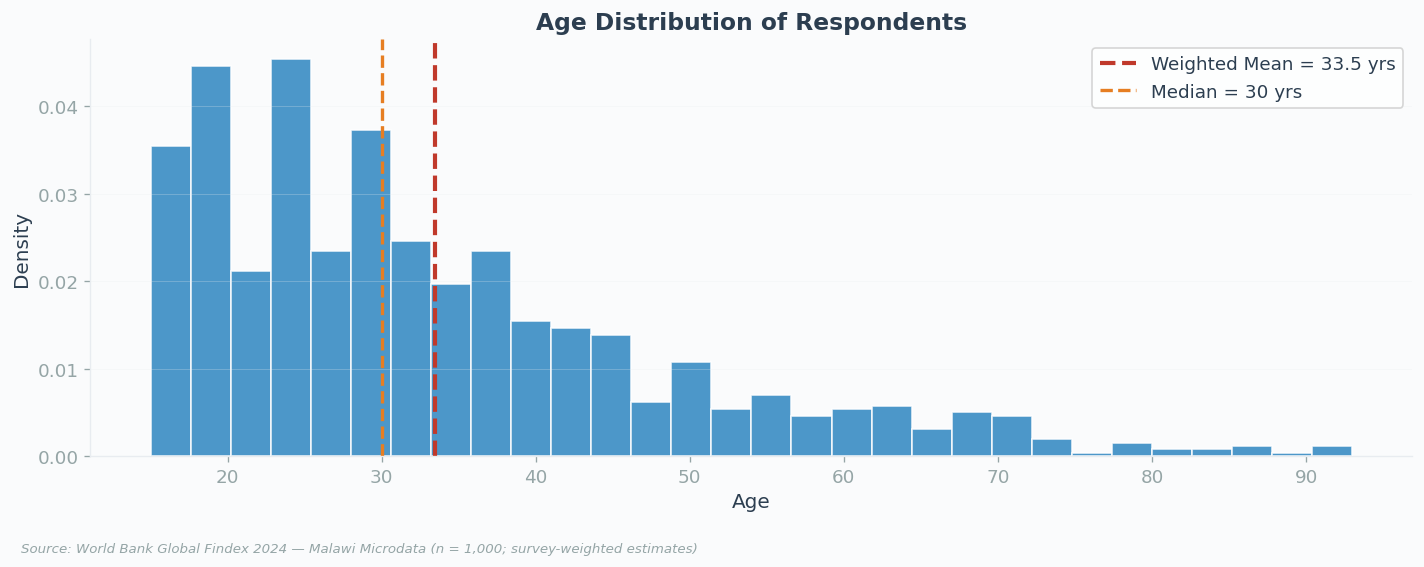

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEMOGRAPHIC PROFILE — KPI Cards + Age Distribution
# ═══════════════════════════════════════════════════════════════════════════════

fem_pct = weighted_mean(df['female'].eq(1), df['wgt']) * 100
rural_pct = weighted_mean(df['urbanicity'].eq(1), df['wgt']) * 100
workforce_pct = weighted_mean(df['emp_in'].eq(1), df['wgt']) * 100
mean_age = np.average(df.loc[df['age'].notna(), 'age'], weights=df.loc[df['age'].notna(), 'wgt'])

kpi_cards([
    ("Female (%)", f"{fem_pct:.0f}%", "♀️", '#E74C3C'),
    ("Rural (%)", f"{rural_pct:.0f}%", "🏡", COLORS['success']),
    ("In Workforce", f"{workforce_pct:.0f}%", "💼", COLORS['secondary']),
    ("Mean Age", f"{mean_age:.0f} yrs", "📅", COLORS['primary']),
])

# ─── Age Distribution ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4.5))
age_data = df['age'].dropna()
ax.hist(age_data, bins=30, color=COLORS['secondary'], edgecolor='white', alpha=0.85, density=True)
ax.axvline(mean_age, color=COLORS['danger'], ls='--', lw=2.5, label=f'Weighted Mean = {mean_age:.1f} yrs')
ax.axvline(age_data.median(), color=COLORS['accent'], ls='--', lw=2, label=f'Median = {age_data.median():.0f} yrs')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution of Respondents', fontweight='bold', fontsize=14)
ax.legend(frameon=True, facecolor='white')
ax.grid(axis='y', alpha=0.45)
add_source_note(fig)
plt.tight_layout()
plt.show()

**Context:** Malawi's adult population is predominantly rural (90%), which has important implications for financial service delivery. The concentration in rural areas means that:

- Physical bank infrastructure reaches only a small fraction of the population
- Mobile money agents and digital channels are critical for inclusion
- Agricultural income patterns create seasonal financial needs

The mean age of 33.5 years indicates a relatively young adult population with:

- Long-term financial planning needs (retirement, education, housing)
- Digital literacy advantages for mobile financial services
- Productive working years ahead requiring credit and savings products

The 56% workforce participation rate reflects:

- Malawi's agrarian economy with informal employment
- Seasonal agricultural work patterns
- Gender differences in formal labor force participation
- Significant informal economic activity

## Key Findings Summary

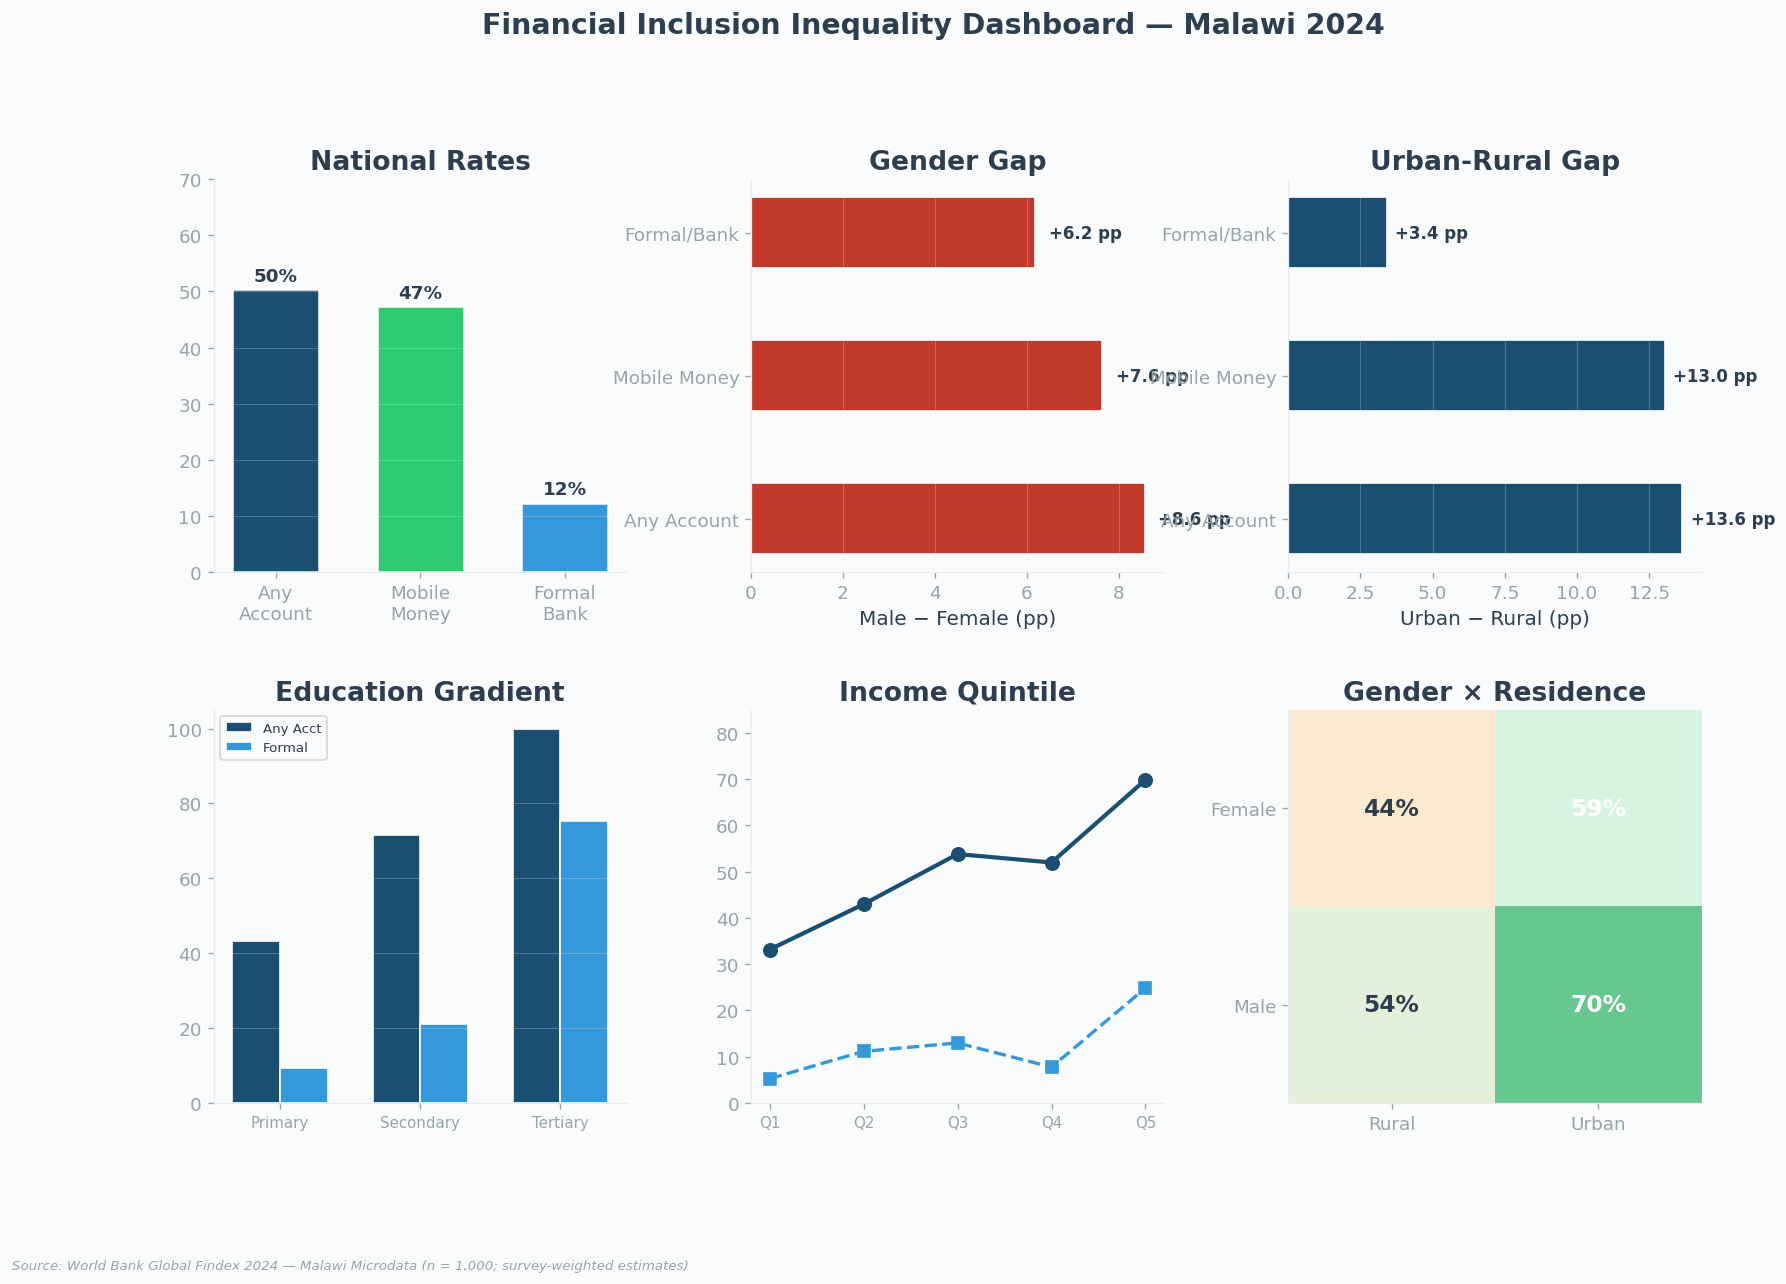

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE INEQUALITY DASHBOARD — All Gaps at a Glance
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# Panel 1: Overall inclusion rates
ax1 = fig.add_subplot(gs[0, 0])
cats = ['Any\nAccount', 'Mobile\nMoney', 'Formal\nBank']
vals = [any_acct, mobile_acct, formal_acct]
cols = [COLORS['total'], COLORS['mobile'], COLORS['bank']]
bars = ax1.bar(cats, vals, color=cols, edgecolor='white', linewidth=1.5, width=0.6)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{bar.get_height():.0f}%', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylim(0, 70); ax1.set_title('National Rates', fontweight='bold'); ax1.grid(axis='y', alpha=0.45)

# Panel 2: Gender gap
ax2 = fig.add_subplot(gs[0, 1])
g_gap = gender_df['Gap (pp)']
colors_gap = [COLORS['danger']]*3
ax2.barh(g_gap.index, g_gap.values, color=colors_gap, edgecolor='white', height=0.5)
for i, v in enumerate(g_gap.values):
    ax2.text(v + 0.3, i, f'{v:+.1f} pp', va='center', fontweight='bold', fontsize=10)
ax2.set_xlabel('Male − Female (pp)'); ax2.set_title('Gender Gap', fontweight='bold')
ax2.grid(axis='x', alpha=0.45)

# Panel 3: Urban-Rural gap
ax3 = fig.add_subplot(gs[0, 2])
r_gap = res_df['Gap (pp)']
ax3.barh(r_gap.index, r_gap.values, color=[COLORS['primary']]*3, edgecolor='white', height=0.5)
for i, v in enumerate(r_gap.values):
    ax3.text(v + 0.3, i, f'+{v:.1f} pp', va='center', fontweight='bold', fontsize=10)
ax3.set_xlabel('Urban − Rural (pp)'); ax3.set_title('Urban-Rural Gap', fontweight='bold')
ax3.grid(axis='x', alpha=0.45)

# Panel 4: Education gradient
ax4 = fig.add_subplot(gs[1, 0])
ed_labels = list(educ_map.values())
ed_any = [education_results_pct[l] for l in ed_labels]
ed_bank = [education_bank_pct[l] for l in ed_labels]
x_ed = np.arange(3)
ax4.bar(x_ed-0.17, ed_any, 0.34, label='Any Acct', color=COLORS['total'], edgecolor='white')
ax4.bar(x_ed+0.17, ed_bank, 0.34, label='Formal', color=COLORS['bank'], edgecolor='white')
ax4.set_xticks(x_ed); ax4.set_xticklabels(['Primary', 'Secondary', 'Tertiary'], fontsize=9)
ax4.set_title('Education Gradient', fontweight='bold'); ax4.legend(fontsize=10); ax4.grid(axis='y', alpha=0.45)

# Panel 5: Income quintile line
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(5), income_results_pct['Any Account (%)'].values, 'o-', color=COLORS['total'], lw=2.5, ms=8)
ax5.plot(range(5), income_results_pct['Formal/Bank (%)'].values, 's--', color=COLORS['bank'], lw=2, ms=7)
ax5.set_xticks(range(5)); ax5.set_xticklabels(['Q1','Q2','Q3','Q4','Q5'], fontsize=9)
ax5.set_title('Income Quintile', fontweight='bold'); ax5.set_ylim(0, 85); ax5.grid(alpha=0.45)

# Panel 6: Intersectional heatmap
ax6 = fig.add_subplot(gs[1, 2])
im = ax6.imshow(gender_residence_pct.values, cmap=cmap, aspect='auto', vmin=30, vmax=75)
ax6.set_xticks([0,1]); ax6.set_xticklabels(['Rural','Urban'])
ax6.set_yticks([0,1]); ax6.set_yticklabels(['Female','Male'])
for i in range(2):
    for j in range(2):
        v = gender_residence_pct.iloc[i,j]
        ax6.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=14,
                fontweight='bold', color='white' if v > 55 else COLORS['text'])
ax6.set_title('Gender × Residence', fontweight='bold')

fig.suptitle('Financial Inclusion Inequality Dashboard — Malawi 2024',
             fontsize=17, fontweight='bold', y=1.02)
add_source_note(fig)
plt.savefig('../outputs/figures/inequality_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXPORT KEY TABLES TO CSV — outputs/tables/
# ═══════════════════════════════════════════════════════════════════════════════
import os
os.makedirs('../outputs/tables', exist_ok=True)

# 1. National financial inclusion indicators
national_indicators = pd.DataFrame({
    'Indicator': ['Any Account', 'Mobile Money Account', 'Formal/Bank Account',
                  'Saved (Any Method)', 'Borrowed (Any Source)', 'Digital Payment Made'],
    'Rate (%)': [
        weighted_mean(df['account'], df['wgt']) * 100,
        weighted_mean(df['account_mob'], df['wgt']) * 100,
        weighted_mean(df['account_fin'], df['wgt']) * 100,
        weighted_mean(df['saved'], df['wgt']) * 100,
        weighted_mean(df['borrowed'], df['wgt']) * 100,
        weighted_mean(df['anydigpayment'], df['wgt']) * 100,
    ]
}).set_index('Indicator')
national_indicators.to_csv('../outputs/tables/national_indicators.csv')

# 2. Account type breakdown
breakdown_export = pd.DataFrame({
    'Category': ['Mobile money only', 'Bank/formal only', 'Both MM & bank', 'No account'],
    'Share (%)': [
        weighted_mean((df['account_mob']==1)&(df['account_fin']==0), df['wgt']) * 100,
        weighted_mean((df['account_mob']==0)&(df['account_fin']==1), df['wgt']) * 100,
        weighted_mean((df['account_mob']==1)&(df['account_fin']==1), df['wgt']) * 100,
        weighted_mean(df['account']==0, df['wgt']) * 100,
    ]
}).set_index('Category')
breakdown_export.to_csv('../outputs/tables/account_type_breakdown.csv')

# 3. Gender gap table
gender_export = gender_df.copy()
gender_export.to_csv('../outputs/tables/gender_gap.csv')

# 4. Education gradient
educ_export = educ_table.copy()
educ_export.to_csv('../outputs/tables/education_gradient.csv')

# 5. Income gradient
income_export = income_results_pct.copy()
income_export.to_csv('../outputs/tables/income_gradient.csv')

print("✅ 5 summary tables exported to outputs/tables/")
print("   • national_indicators.csv")
print("   • account_type_breakdown.csv")
print("   • gender_gap.csv")
print("   • education_gradient.csv")
print("   • income_gradient.csv")

✅ 5 summary tables exported to outputs/tables/
   • national_indicators.csv
   • account_type_breakdown.csv
   • gender_gap.csv
   • education_gradient.csv
   • income_gradient.csv


## Recommendations for Further Analysis

Based on these descriptive findings, the following areas warrant deeper investigation:

1. **Barriers to Financial Inclusion:**
   - **Research Questions:**
     - Why do 50% of Malawian adults remain unbanked?
     - What are the primary barriers for different demographic groups?
     - Which barriers are most binding and addressable through policy?
   - **Key Variables to Analyze:**
     - Reasons for not having bank/formal account (`fin11a-f`) including too far, too expensive, lack documentation, lack money, family member has one, lack trust
     - Reasons for not having mobile money account (`fin14a-e`) (Sub-Saharan Africa only)
   - **Expected Insights:**
     - Which barriers affect the most people?
     - Do barriers differ by gender, residence, income?
     - Are cost barriers more important than distance barriers?

---
2. **Account Usage and Activity Patterns:**
   - **Research Questions:**
     - Do account holders actively use their accounts?
     - What distinguishes active from dormant accounts?
     - How frequently do people deposit and withdraw?
   - **Key Variables to Analyze:**
     - Frequency of deposits into accounts (`fin5`)
     - Frequency of withdrawals from accounts (`fin6`)
     - Any deposits or withdrawals (`fin7`)
     - Store money in account (`fin8`)
     - Mobile money transaction frequency (`fin13a-c`)
   - **Expected Insights:**
     - What percentage of accounts are actively used vs. dormant?
     - Do mobile money accounts see more activity than bank accounts?
     - What predicts active account usage?

---
3. **Mobile Money Deep Dive:**
   - **Research Questions:**
     - How do people use mobile money in Malawi?
     - What are security concerns and fraud experiences?
     - Why has mobile money succeeded where banks haven't?
   - **Key Variables to Analyze:**
     - Store money in mobile money account (`fin13d`)
     - Asked for mobile money PIN/password (security) (`fin13e`)
     - Sent money to wrong number (`fin13f`)
     - Received money back after error (`fin13f_1`)
     - Use of agents for transactions (`fin15`)
   - **Expected Insights:**
     - What makes mobile money appealing vs. bank accounts?
     - How serious are security concerns and fraud?
     - Do people store money in mobile money or just transact?

---
4. **Digital Payments and Merchant Acceptance:**
   - **Research Questions:**
     - Why is merchant payment adoption so low (10%) compared to digital transfers (49%)?
     - What are barriers to digital merchant payments?
   - **Key Variables to Analyze:**
     - Used card/phone for in-store purchases (`fin25e2`)
     - Frequency of digital in-store payments (`fin25e3`)
     - Main reason for only using cash in stores (`fin25e4`)
     - Used phone/computer to make bill payments (`fin26a`)
     - Bought something online (`fin26b`)
   - **Expected Insights:**
     - Is it merchant acceptance or consumer preference limiting adoption?
     - What would increase digital merchant payments?

---
5. **Government-to-Person (G2P) Payments:**
   - **Research Questions:**
     - How do government payment methods affect financial inclusion?
     - Does receiving government payments digitally lead to broader account usage?
   - **Key Variables to Analyze:**
     - Received financial support from government (`fin37`)
     - Received public sector pension (`fin38`)
     - Payment method (account, mobile, cash, card) (`fin39a-d`)
     - Withdrawal behavior (`fin40`)
     - Unexpected fees (`fin41`)
   - **Expected Insights:**
     - Do government digital payments drive financial inclusion?
     - What are pain points in G2P payment systems?

---
6. **Financial Resilience and Emergency Preparedness:**
   - **Research Questions:**
     - How financially resilient are Malawian households?
     - What are emergency fund sources?
     - How do natural disasters affect financial access?
   - **Key Variables to Analyze:**
     - Main source of emergency funds (`fin24`)
     - Difficulty obtaining emergency funds (`fin24a`)
     - How long household could cover expenses if income lost (`fin24b`)
     - Experienced natural disaster (`fin24c`)
     - Natural disaster impacts (income loss, property damage, account access) (`fin24d1-3`)
   - **Expected Insights:**
     - How many people could handle a financial emergency?
     - Does account ownership correlate with financial resilience?
     - How do natural disasters disrupt financial access?

---

## Next Steps

### Notebook 03: Barriers to Financial Inclusion Analysis

**Objectives:**
- Conduct comprehensive analysis of barriers preventing account ownership
- Disaggregate barriers by demographic groups (gender, residence, income, education)
- Identify most binding constraints
- Generate policy recommendations for reducing barriers

**Key Variables:**
- `fin11a-f`: Reasons for not having bank/formal account
- `fin14a-e`: Reasons for not having mobile money account (SSA only)
- `fin11_2`: Could use account without help
- `fin13_1`: Mobile money meets financial needs

**Expected Deliverables:**
- Barrier prevalence tables by demographic group
- Statistical analysis of barrier differences
- Visualization of barrier profiles
- Policy recommendation matrix

---

### Notebook 04: Account Usage and Behavioral Patterns

**Objectives:**
- Analyze account activity levels and usage patterns
- Compare bank vs. mobile money usage intensity
- Examine digital payment adoption drivers
- Profile active vs. dormant account holders

**Key Variables:**
- Transaction frequency: `fin5`, `fin6`, `fin7`, `fin13a-c`
- Account storage: `fin8`, `fin13d`
- Digital payments: `fin25e2-4`, `fin26a-b`
- Payment channels and preferences

**Expected Deliverables:**
- Account activity classification and distribution
- Usage pattern comparisons (bank vs. mobile money)
- Digital payment adoption analysis
- Recommendations for increasing active usage

---

## Technical Notes

### Methodological Details

**Survey Weights:**
- All statistics use the `wgt` variable to ensure national representativeness
- Weights account for sampling design and non-response
- Sum of weights approximately equals adult population (15+)

**Missing Values:**
- Missing values are structural (survey skip logic), not data quality issues
- Questions have specific eligibility criteria (e.g., asked only of account holders)
- Missing values handled through conditional exclusion in weighted calculations
- No imputation or global deletion performed

**Variable Coding:**

- **Constructed variables (account, saved, borrowed, etc.): Binary 0/1**
  - 1 = Yes, 0 = No
  - Include additional cases identified through skip logic
  - Created by World Bank, documented in codebook

- **Questionnaire variables (fin17a, fin25e2, etc.): Response codes 1/2/3/4**
  - 1 = Yes, 2 = No, 3 = Don't know, 4 = Refused
  - Direct survey responses
  - Subject to skip logic (many missing by design)

- **Demographic variables: Specific coding schemes**
  - `female`: 1 = Female, 2 = Male
  - `urbanicity`: 1 = Rural, 2 = Urban
  - `educ`: 1 = Primary or less, 2 = Secondary, 3 = Tertiary or more
  - `inc_q`: 1 = Poorest 20%, 2-4 = Middle quintiles, 5 = Richest 20%

---

### Codebook Reference

- "Don't know" and "Refused" responses are coded as 'no' in Global Findex country-level database
- In microdata, these responses are preserved as separate codes
- Some questions are region-specific (e.g., mobile money questions more detailed in Sub-Saharan Africa)
- Constructed variables may include respondents not initially reporting ownership but identified through other questions
- Always consult codebook for proper variable interpretation

---

### Interpretation Cautions

- Percentages with different denominators are not directly comparable
- Conditional statistics (e.g., "among account holders") noted explicitly
- Overlapping categories (e.g., mobile money and bank accounts) may sum to >100%
- Statistical significance testing not performed (descriptive analysis only)
- Causation cannot be inferred from cross-sectional correlations

---

## Data Source Information

**Dataset:** World Bank Global Findex Database 2024  
**Country:** Malawi  
**Sample Size:** 1,000 adults (age 15+)  
**Survey Period:** 2024  
**Survey Method:** Face-to-face interviews  
**Survey Firm:** Gallup World Poll  
**Sampling:** Nationally representative probability sample  
**Weighting:** Survey weights provided to adjust for sampling design and non-response  
**Official Codebook:** codebook_microdata_2025.pdf (see data/raw/ directory)

**Citation:**
- Demirgüç-Kunt, A., Klapper, L., Singer, D., & Ansar, S. (2024). *The Global Findex Database 2024: Financial Inclusion, Digital Payments, and Resilience in the Age of COVID-19*. World Bank, Washington, DC.

**Data Access:**
- Microdata available through World Bank Microdata Library
- Requires registration and agreement to terms of use
- Data cannot be shared or redistributed
- For research and policy analysis only

---

## Reproducibility Information

**Software Environment:**
- Python 3.13
- pandas (data manipulation)
- numpy (numerical computing)
- matplotlib (visualization)

---

## To Reproduce This Analysis

- Download Malawi microdata from World Bank Microdata Library
- Place CSV file in data/raw/ directory
- Ensure codebook PDF is in data/raw/ directory
- Run notebooks in numerical order (01 → 02 → 03 → 04)
- Each notebook is self-contained and reloads data from disk

---

## About This Project

**Author:** Brian Thuwala  
**Project Type:** Portfolio Data Analysis Project  
**Purpose:** Demonstrate survey data analysis, statistical programming, and policy research skills for financial inclusion analysis  

**Skills Demonstrated:**
- Survey methodology and weighted statistics
- Data validation and quality assurance
- Descriptive statistical analysis
- Cross-tabulation and disaggregation
- Professional documentation and reporting
- Policy-relevant research design
- Clear communication of technical findings

---

**End of Notebook 02: Descriptive Analysis**  
**Next → Notebook 03: Barriers to Financial Inclusion Analysis**